# Activation Functions

An **activation function** is a nonlinear function applied *after* the weighted sum at each node. Without activation functions, the hidden layers would just be doing linear math — no better than a single linear regression.

**Why do we need them?**
- They introduce **nonlinearity**, letting the network learn complex patterns
- They decide how much of a signal should pass forward (like a gate)
- Without them, stacking layers would be pointless

---

## ReLU (Rectified Linear Unit)

**Used in:** Hidden layers

**Rule:** If the input is negative → output 0. If positive → leave it as is.

$$ \text{ReLU}(x) = \max(0, x) $$

**Why is it popular?**
- Fast to compute
- Prevents the **vanishing gradient problem** (where slopes get so tiny that training stalls)

ReLU function: Max(0, x)


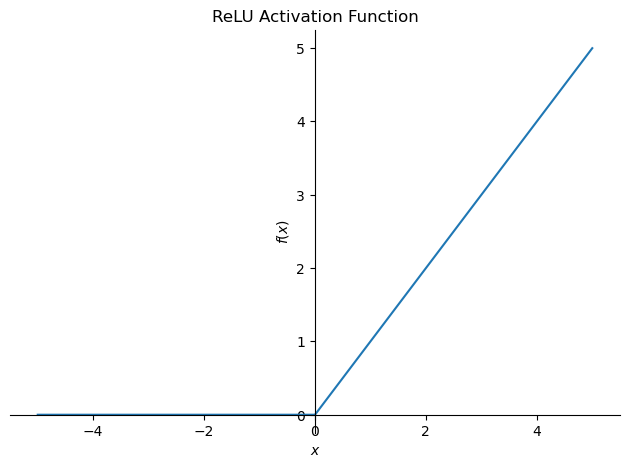

In [1]:
from sympy import *

x = symbols('x')

# ReLU function
relu = Max(0, x)
print("ReLU function:", relu)

# Plot it
plot(relu, (x, -5, 5), title='ReLU Activation Function')

## Logistic (Sigmoid) Function

**Used in:** Output layer (for binary classification)

**Rule:** Squashes any value into the range **(0, 1)** — perfect for outputting probabilities.

$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

If you've done logistic regression, this is the same function! So logistic regression is essentially acting as a *layer* inside the neural network.

Logistic function: 1/(1 + exp(-x))


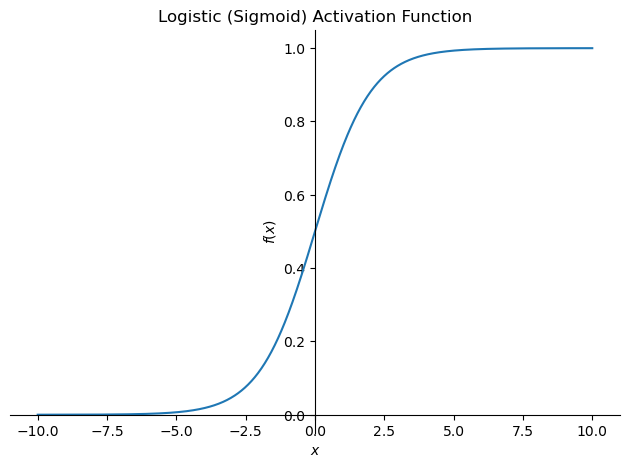

In [2]:
# Logistic (Sigmoid) function
logistic = 1 / (1 + exp(-x))
print("Logistic function:", logistic)

# Plot it
plot(logistic, (x, -10, 10), title='Logistic (Sigmoid) Activation Function')

## Common Activation Functions — Quick Reference

| Name | Where Used | What It Does | Notes |
| --- | --- | --- | --- |
| **Linear** | Output | Leaves values as is | Rarely used |
| **Logistic (Sigmoid)** | Output | S-curve, squashes to (0, 1) | Binary classification |
| **Tanh** | Hidden | S-curve, squashes to (-1, 1) | Centers data around 0 |
| **ReLU** | Hidden | Zeros out negatives | Fast, prevents vanishing gradients |
| **Leaky ReLU** | Hidden | Negatives × 0.01 | Variant: keeps a tiny signal for negatives |
| **Softmax** | Output | All outputs sum to 1.0 | Multi-class classification |

### Rule of Thumb
- **Hidden layers →** use **ReLU**
- **Output layer (binary) →** use **Logistic (Sigmoid)**
- **Output layer (multi-class) →** use **Softmax**

## Activated vs Unactivated Output

- **Unactivated output (Z):** The raw weighted sum → `Z = W·X + B`
- **Activated output (A):** After passing through the activation function → `A = f(Z)`

The activation function can **strengthen**, **weaken**, or **leave unchanged** the signal. This is where the "brain synapse" metaphor comes from.

---

## Multiple Output Classes

Our example has 2 classes (light/dark font), modeled with 1 output node.

For **multiple classes** (e.g., recognizing digits 0–9), you'd have:
- **10 output nodes** (one per class)
- Each outputs a probability
- Use **softmax** so all probabilities sum to 1.0

In [3]:
import numpy as np

# NumPy implementations of activation functions
relu_np = lambda x: np.maximum(x, 0)
logistic_np = lambda x: 1 / (1 + np.exp(-x))

# Demo: passing values through each
test_values = np.array([-3, -1, 0, 1, 3])

print("Input values:  ", test_values)
print("After ReLU:    ", relu_np(test_values))
print("After Sigmoid: ", np.round(logistic_np(test_values), 4))

Input values:   [-3 -1  0  1  3]
After ReLU:     [0 0 0 1 3]
After Sigmoid:  [0.0474 0.2689 0.5    0.7311 0.9526]


## Key Takeaways

1. **Activation functions add nonlinearity** — without them, a neural network is just a fancy linear regression
2. **ReLU** is the go-to for hidden layers (fast, avoids vanishing gradients)
3. **Sigmoid** is used in the output layer for binary classification (outputs a probability 0–1)
4. **Softmax** is used when you have more than 2 classes
5. The output after applying an activation function is called the **activated output (A)**